## Imports

In [2]:
import torch
import numpy as np
import torch.nn as nn
from torch.distributions import Normal, Categorical
from torch.distributions.multivariate_normal import MultivariateNormal
from torch.distributions.mixture_same_family import MixtureSameFamily
import matplotlib.pyplot as plt
import torch.nn.functional as F
from utils import style_plot

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams['font.family'] = ['CMU Serif', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

## Generating distributions

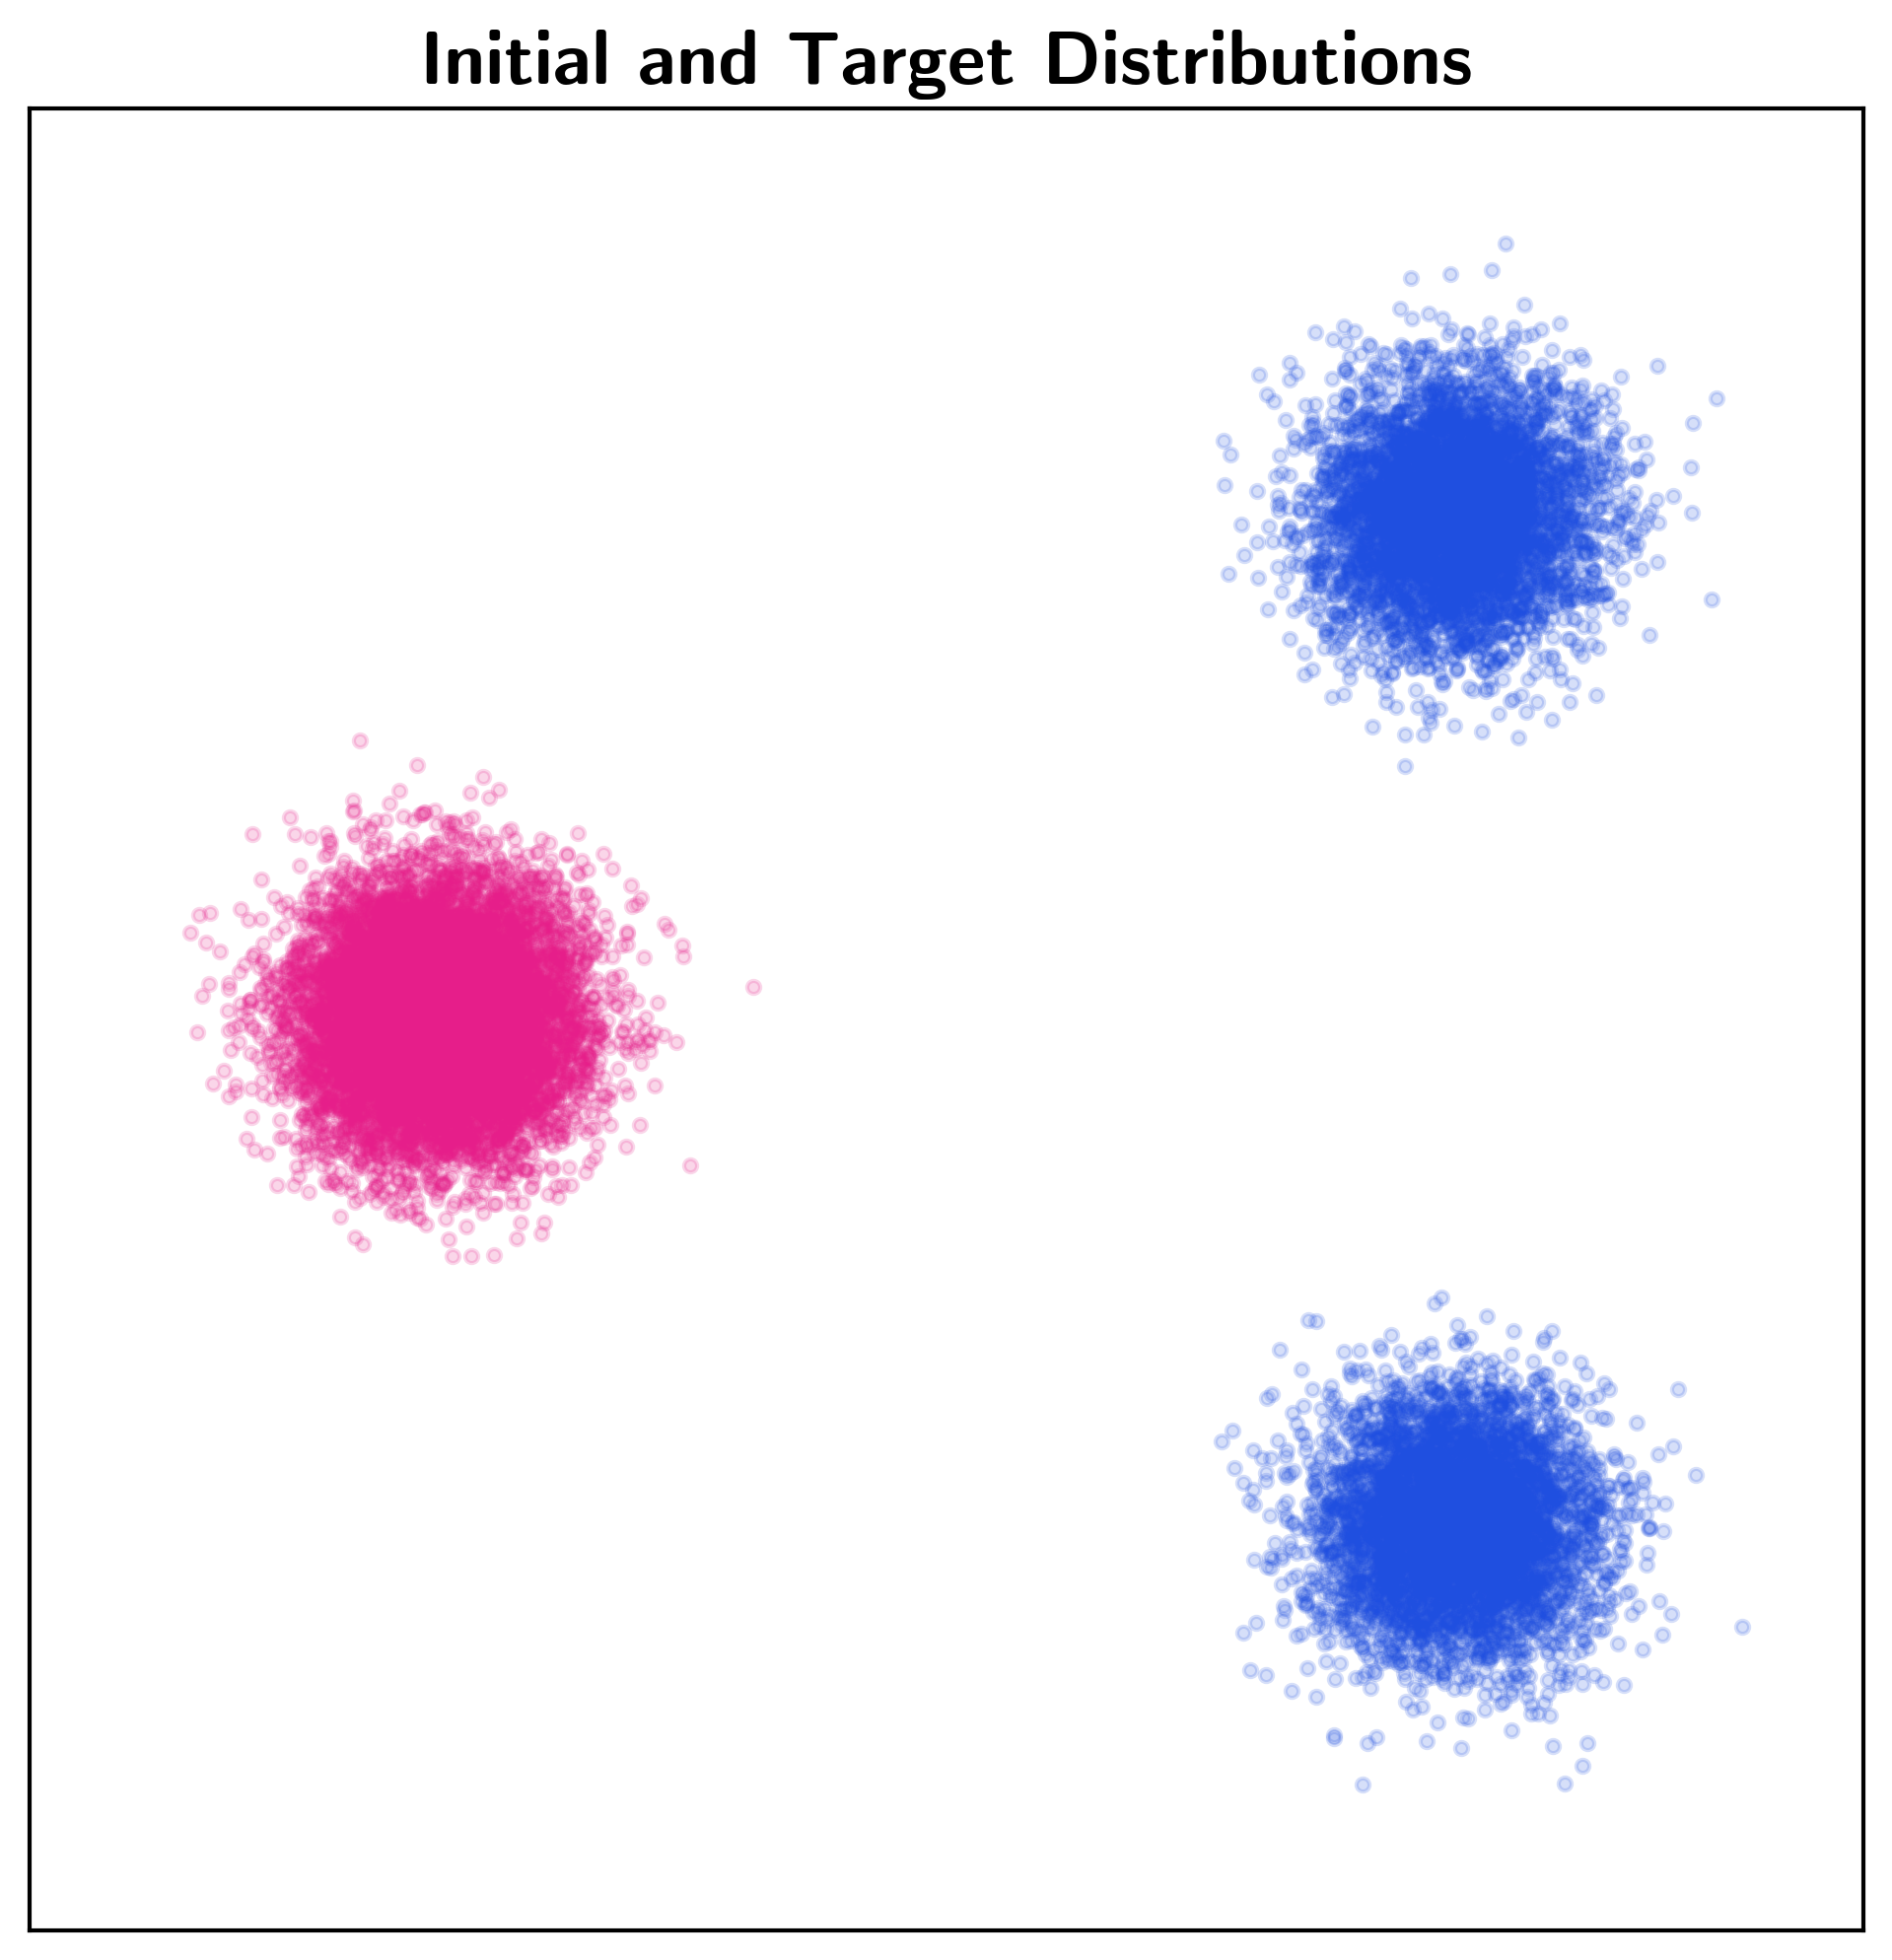

In [5]:
# Parameters
D = 5.0
M = D + 4
VAR = 0.45
N_SAMPLES = 10000

# Initial distribution (unimodal Gaussian)
initial_mean = torch.tensor([-D, 0]).float()
initial_model = torch.distributions.Normal(initial_mean, torch.sqrt(torch.tensor(VAR)))
samples_0 = initial_model.sample([N_SAMPLES])

# Target distribution
target_means = torch.tensor([
    [ D,  D],
    [ D, -D],
]).float()
COMP = 2
target_mix = Categorical(torch.tensor([1 / COMP for _ in range(COMP)]))

target_comp = MultivariateNormal(target_means,VAR * torch.stack([torch.eye(2) for _ in range(COMP)]))
target_model = MixtureSameFamily(target_mix, target_comp)
samples_1 = target_model.sample([N_SAMPLES])

# Plot
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

# Scatter plots
ax.scatter(
    samples_0[:, 0].numpy(),
    samples_0[:, 1].numpy(),
    s=10,
    alpha=0.18,
    color='#E61E8A',
    label=r'$\pi_0$'
)

ax.scatter(
    samples_1[:, 0].numpy(),
    samples_1[:, 1].numpy(),
    s=10,
    alpha=0.18,
    color='#1F4FE0',
    label=r'$\pi_1$'
)

ax = style_plot(ax, M, title='Initial and Target Distributions', legend=False)

plt.show()

## Define flow model

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim=2, hidden_num=100):
        super().__init__()
        self.fc1 = nn.Linear(input_dim+1, hidden_num, bias=True)
        self.fc2 = nn.Linear(hidden_num, hidden_num, bias=True)
        self.fc3 = nn.Linear(hidden_num, input_dim, bias=True)
        self.act = lambda x: torch.tanh(x)
    
    def forward(self, x_input, t):
        inputs = torch.cat([x_input, t], dim=1)
        x = self.fc1(inputs)
        x = self.act(x)
        x = self.fc2(x)
        x = self.act(x)
        x = self.fc3(x)

        return x

In [7]:
class RectifiedFlow():
  def __init__(self, model=None, num_steps=1000):
    self.model = model
    self.N = num_steps
  
  def get_train_tuple(self, z0=None, z1=None):
    t = torch.rand((z1.shape[0], 1))
    z_t =  t * z1 + (1.-t) * z0
    target = z1 - z0 
    
    # Training objective is vanilla flow matching
    return z_t, t, target

  @torch.no_grad()
  def sample_ode(self, z0=None, N=None):
    ### NOTE: Use Euler method to sample from the learned flow
    if N is None:
      N = self.N    
    dt = 1./N
    traj = [] # to store the trajectory
    z = z0.detach().clone()
    batchsize = z.shape[0]
    
    traj.append(z.detach().clone())
    for i in range(N):
      t = torch.ones((batchsize,1)) * i / N
      pred = self.model(z, t)
      z = z.detach().clone() + pred * dt
      
      traj.append(z.detach().clone())

    return traj

In [8]:
def train_rectified_flow(rectified_flow, optimizer, pairs, batchsize, inner_iters):
  loss_curve = []
  for i in range(inner_iters+1):
    optimizer.zero_grad()
    indices = torch.randperm(len(pairs))[:batchsize]
    batch = pairs[indices]
    z0 = batch[:, 0].detach().clone()
    z1 = batch[:, 1].detach().clone()
    z_t, t, target = rectified_flow.get_train_tuple(z0=z0, z1=z1)

    pred = rectified_flow.model(z_t, t)
    loss = (target - pred).view(pred.shape[0], -1).abs().pow(2).sum(dim=1)
    loss = loss.mean()
    loss.backward()
    
    optimizer.step()
    loss_curve.append(np.log(loss.item())) ## to store the loss curve

    if inner_iters < 50000:
      if i % 1000 == 0:
        print(f'Iteration: {i}, Loss: {loss.item():.4f}')
    else:
      if i % 10000 == 0:
        print(f'Iteration: {i}, Loss: {loss.item():.4f}')

  return rectified_flow, loss_curve


In [16]:
@torch.no_grad()
def draw_plot(rectified_flow, z0, z1, N=100, title="DistributionTransport"):
    traj = rectified_flow.sample_ode(z0=z0, N=N)
    traj_particles = torch.stack(traj)
    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

    for i in range(30):
        ax.plot(traj_particles[:, i, 0].cpu().numpy(), traj_particles[:, i, 1].cpu().numpy(),
                color='gray',alpha=0.22,linewidth=1.0, zorder=1
            )

    ax.scatter(z1[:, 0].cpu().numpy(), z1[:, 1].cpu().numpy(),
                label=r'$\pi_1$',
                color='#1F4FE0',
                alpha=0.15,
                s=10,
                zorder=2
            )

    ax.scatter(traj[0][:, 0].cpu().numpy(), traj[0][:, 1].cpu().numpy(),
                label=r'$\pi_0$',
                color='#E61E8A',
                alpha=0.15,
                s=10,
                zorder=2
            )
    
    # Generated samples
    ax.scatter(traj[-1][:, 0].cpu().numpy(), traj[-1][:, 1].cpu().numpy(),
                label='Generated',
                color="#1F4FE0",
                alpha=0.22,
                s=10,
                zorder=3
            )

    ax = style_plot(ax, M, title=title, legend=False)
    plt.show()

## 1-Rectified Flow (Vanilla Flow Matching)

In [10]:
x_0 = samples_0.detach().clone()[torch.randperm(len(samples_0))]
x_1 = samples_1.detach().clone()[torch.randperm(len(samples_1))]
x_pairs = torch.stack([x_0, x_1], dim=1)
print(x_pairs.shape)

torch.Size([10000, 2, 2])


Iteration: 0, Loss: 130.5713
Iteration: 1000, Loss: 5.1083
Iteration: 2000, Loss: 4.9639
Iteration: 3000, Loss: 4.6247
Iteration: 4000, Loss: 4.8874
Iteration: 5000, Loss: 4.6678
Iteration: 6000, Loss: 5.3050
Iteration: 7000, Loss: 4.7988
Iteration: 8000, Loss: 4.7586
Iteration: 9000, Loss: 4.9531
Iteration: 10000, Loss: 4.9787


Text(0.5, 1.0, 'Training Loss Curve')

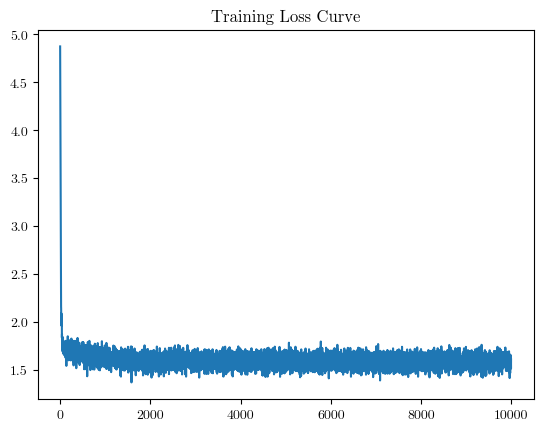

In [11]:
iterations = 10000
batchsize = 2048
input_dim = 2

rectified_flow_1 = RectifiedFlow(model=MLP(input_dim, hidden_num=100), num_steps=100)
optimizer = torch.optim.Adam(rectified_flow_1.model.parameters(), lr=5e-3)

rectified_flow_1, loss_curve = train_rectified_flow(rectified_flow_1, optimizer, x_pairs, batchsize, iterations)
plt.plot(np.linspace(0, iterations, iterations+1), loss_curve[:(iterations+1)])
plt.title('Training Loss Curve')

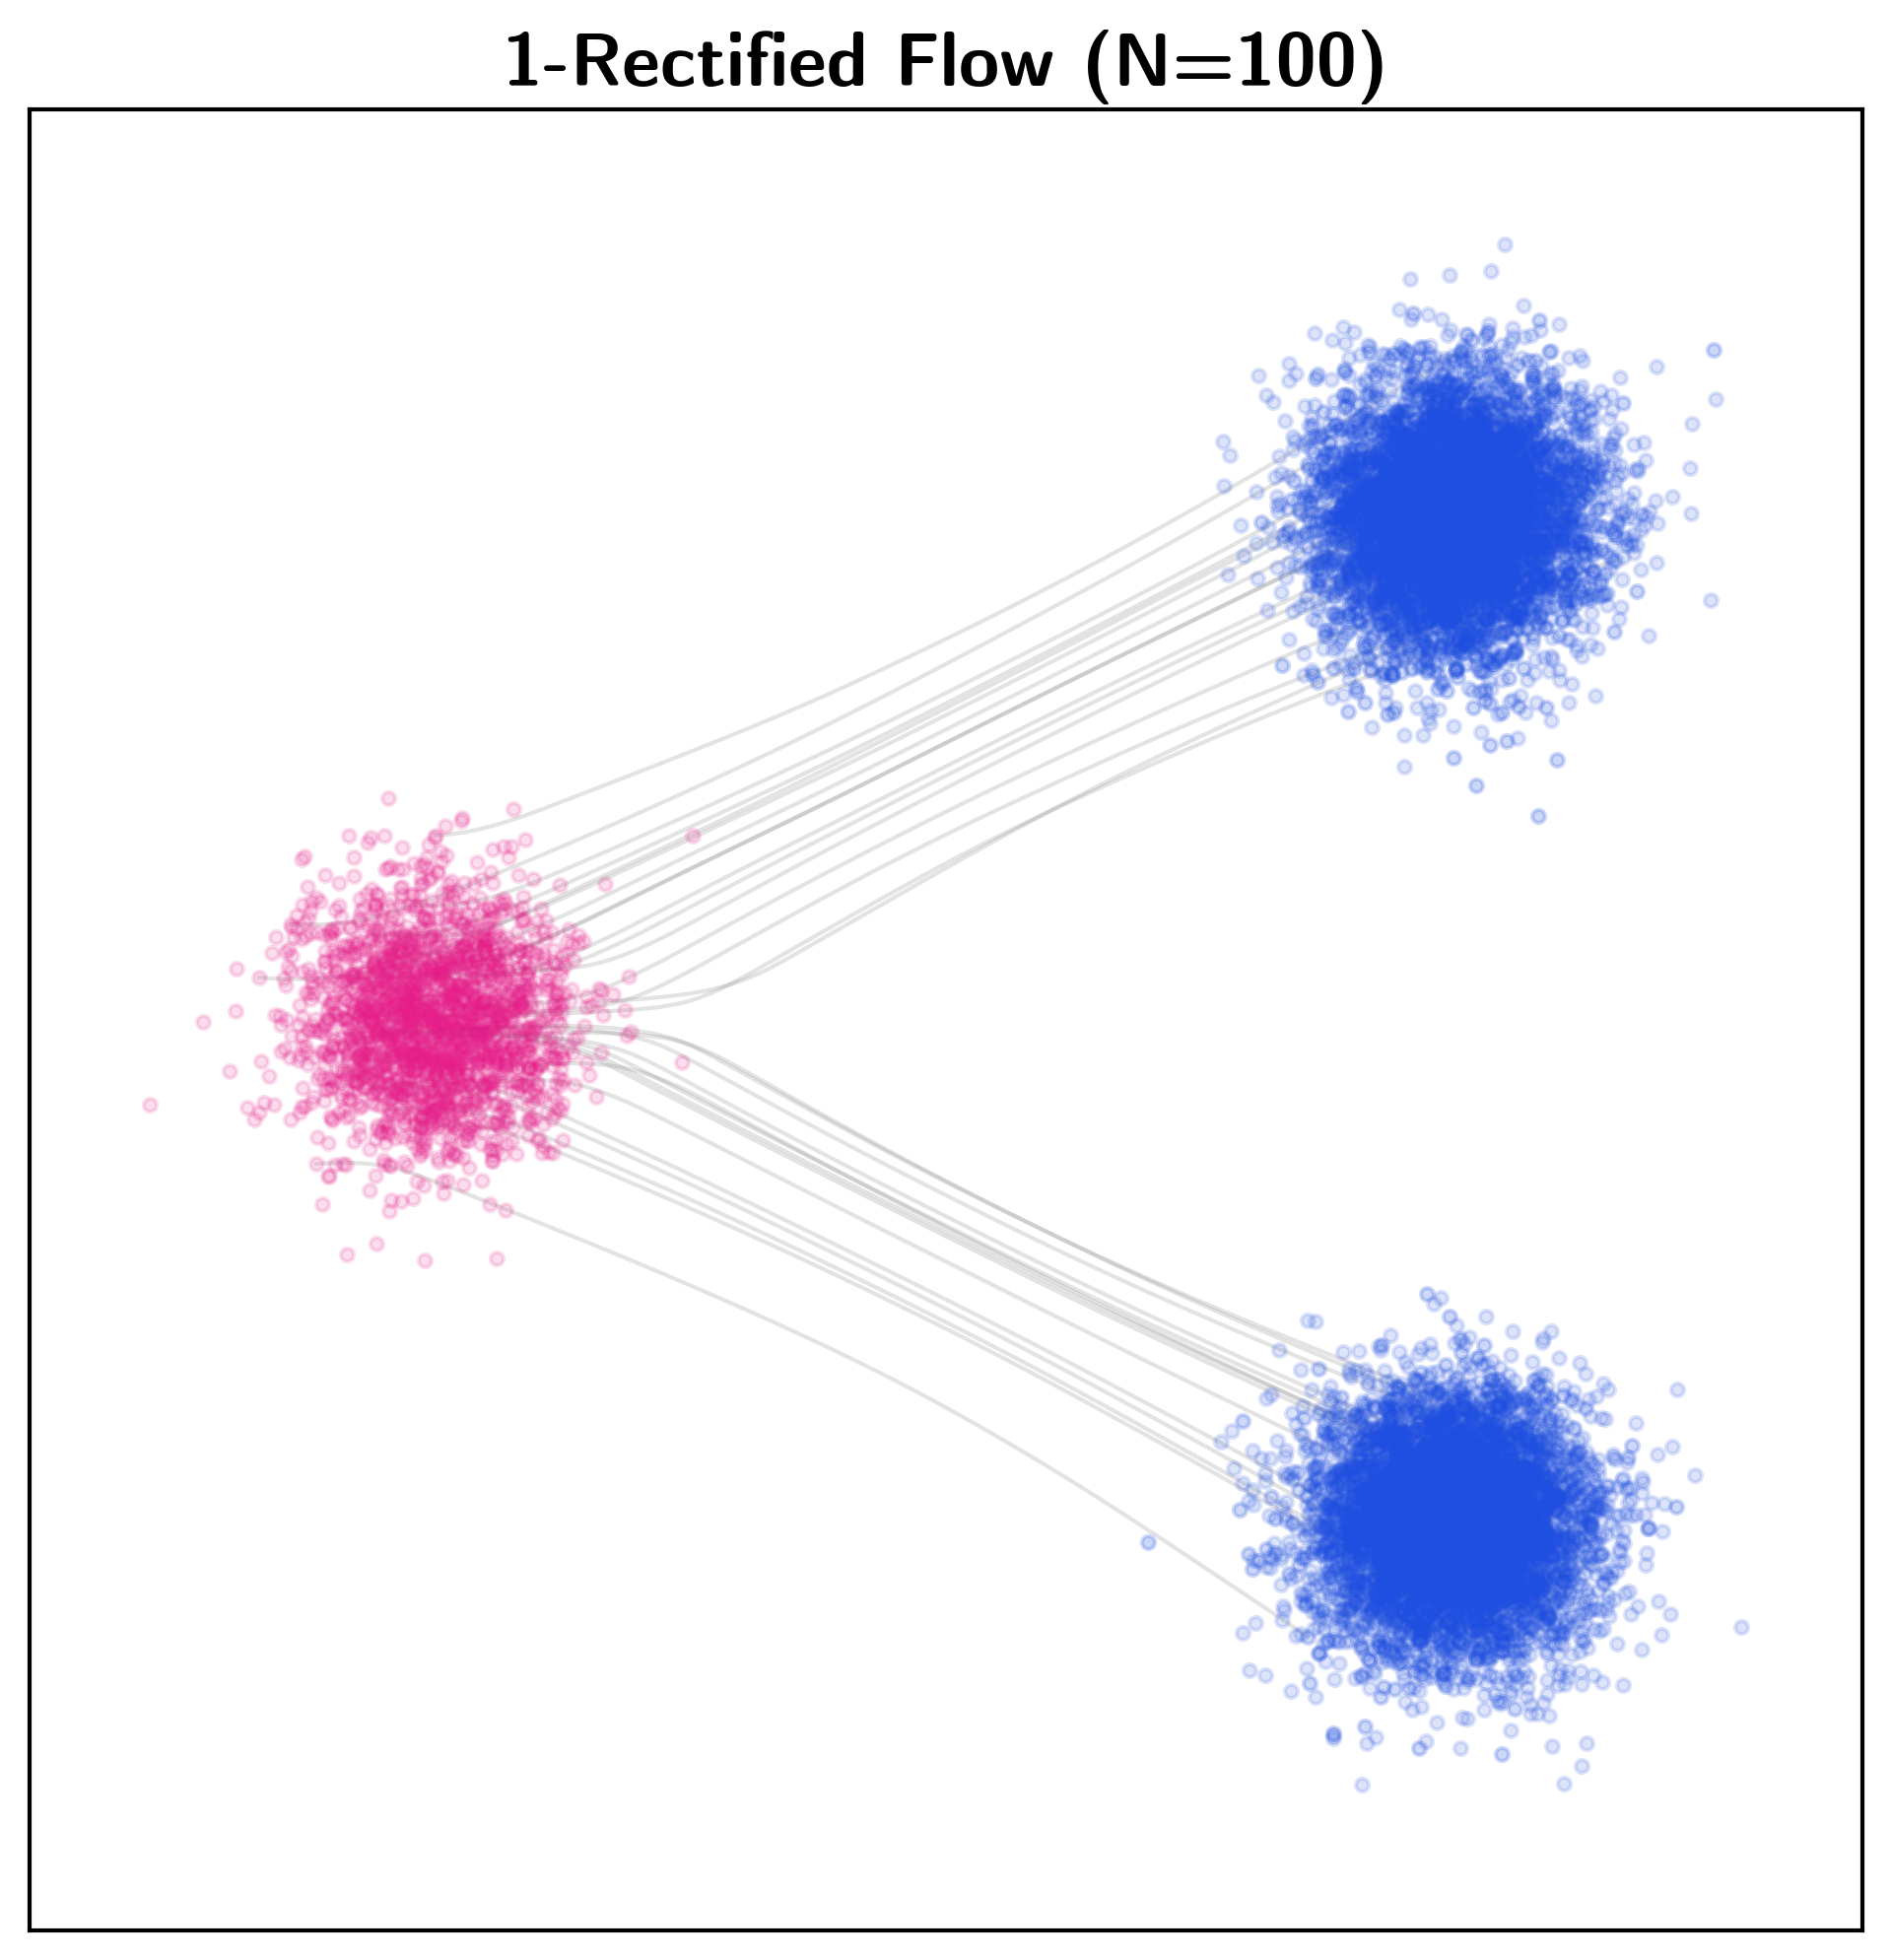

In [17]:
# Follow trajectory in 100 steps
SEED = 4
torch.manual_seed(SEED)
np.random.seed(SEED)
draw_plot(rectified_flow_1,
          z0=initial_model.sample([2000]),
          z1=samples_1.detach().clone(),
          N=100,
          title="1-Rectified Flow (N=100)")

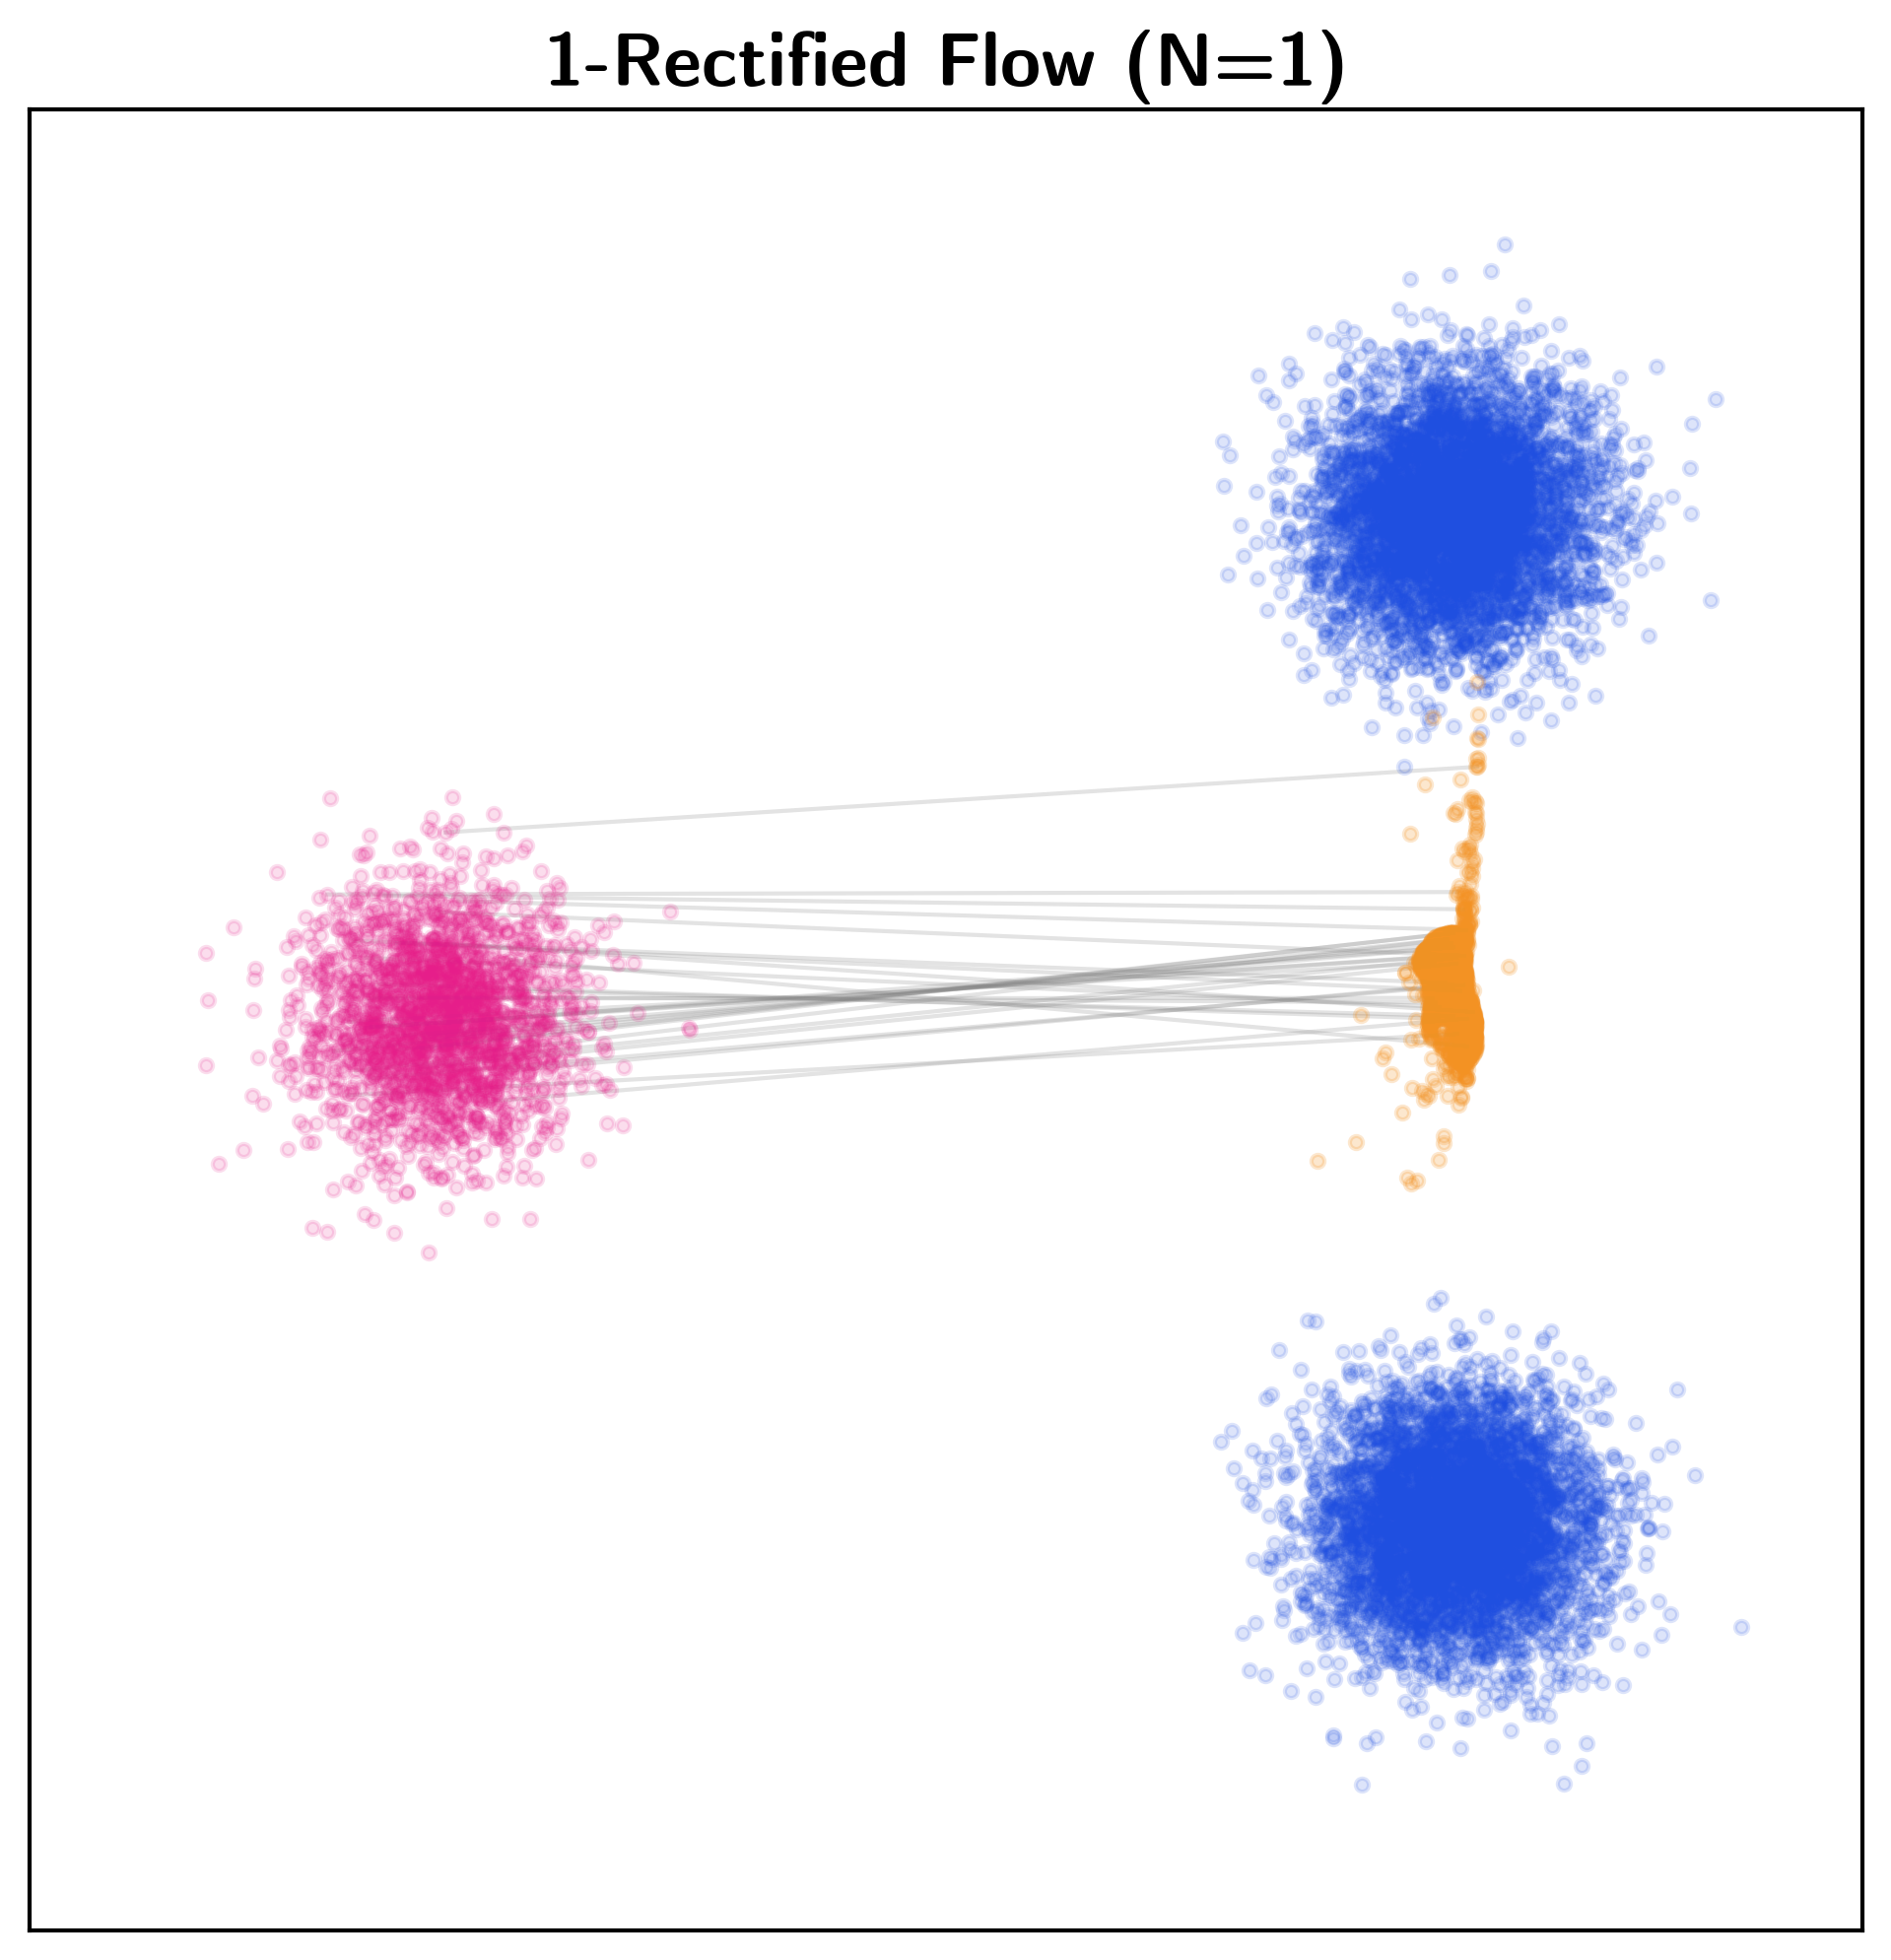

In [15]:
# Follow trajectory in 1 step
SEED = 2
torch.manual_seed(SEED)
np.random.seed(SEED)
draw_plot(rectified_flow_1, 
          z0=initial_model.sample([2000]), 
          z1=samples_1.detach().clone(),
          N=1,
          title="1-Rectified Flow (N=1)")